# Assignment 2: Crop Classification from Satellite Imagery

- **Course:** ECE414 — Fundamentals of Remote Sensing and Earth Observation
- **Instructor:** Krishna Karra (krishna.karra@cooper.edu — Teams chat is quickest)
- **Assigned:** Wednesday, March 11, 2026
- **Due:** Sunday, March 29, 2026 (by midnight EST)

---

## The Scenario

You are a researcher in a remote sensing lab. Your lab director has secured a pilot contract to explore whether satellite imagery can be used to classify crop types across the U.S. Midwest — potentially months before official maps are released.

The USDA's [Cropland Data Layer (CDL)](https://www.nass.usda.gov/Research_and_Science/Cropland/SARS1a.php) is the gold standard for crop mapping in the Continental United States — a 30-meter annual map of crop types produced using Landsat and other satellite data. However, each year's CDL isn't released until well into the following year. If crop types could be predicted *in-season*, it would be transformative for crop monitoring, yield forecasting, agricultural policy, and environmental management.

Your lab director wants two things from you:

1. **A working prototype** — an end-to-end system that takes satellite imagery as input and produces a crop type classification map as output.
2. **A technical write-up** — a notebook documenting your methodology, experiments, results, and analysis. The write-up should be thorough enough that another researcher in the lab could understand and reproduce your work.

Your study region is **Iowa and Illinois**. The year you're working with is **2023** — this means you'll use 2023 Landsat imagery as your satellite data and the 2023 CDL as your ground truth for training and evaluation.

---

## Your Mission

Build an end-to-end crop classification system using Google Earth Engine and the Python API. Your system should:

- Identify the dominant crops grown in the study region
- Characterize how those crops behave spectrally across the growing season
- Train a classifier that predicts crop type from satellite imagery
- Deploy the classifier to new areas and assess how well it generalizes

The assignment is structured as four phases. Each phase builds on the previous one.

---

## Phase 1: Landscape Assessment

**Goal:** Determine which crops dominate the agricultural landscape in Iowa and Illinois.

**Deliverables:**
- A ranked table showing the most prevalent crops across Iowa and Illinois by area, computed from the 2023 CDL
- Identify the **top 5 most prevalent crops** — these will be your target classes for the rest of the assignment
- At least one visualization that supports your findings

**Things to think about:**
- The landscape contains far more than 5 crop types. When you deploy a classifier for only 5 crops, what happens to all the other pixels?
- How dominant are the top 5 compared to everything else?

---

## Phase 2: Crop Phenology Exploration

**Goal:** Understand how your target crops behave spectrally across the growing season, and use this understanding to inform your modeling approach.

**Deliverables:**
- Sampled pixel locations for each target crop class across the study region
- Time series plots showing the seasonal spectral behavior of each crop, with measures of central tendency and variability
- Written analysis connecting what you observe in the time series to what you expect for classification — which crops will be easy to separate? Which will be hard? When during the year are differences most pronounced?

**Things to think about:**
- How do you ensure your samples are representative of the full study region?
- What spectral index (or indices) best captures crop phenology, and why?
- How do you handle noisy or missing observations in the time series?

---

## Phase 3: Classification System

**Goal:** Design, train, and rigorously evaluate a pixel-level crop classification model for your top 5 crops.

**Deliverables:**
- A trained classifier that takes Landsat imagery features as input and predicts crop type
- A justification of your feature engineering choices — what inputs did you give the model, and why?
- Evaluation on a held-out test set including: confusion matrix, per-class precision, recall, and F1 score
- Error analysis — where does the model succeed and fail? Do the errors make sense given what you learned in Phase 2?
- Discussion of model iteration — what did you try, what worked, and what didn't?

**Important note on approach:** Start by building a classifier that uses a **full year's worth of Landsat imagery** (all of 2023). Getting a working end-to-end system with full-year data is the core requirement and will earn you full credit. Once you have that working, you can optionally explore whether your model can achieve reasonable performance with less data — for example, using only imagery up through July or August. This "in-season" prediction is the real-world motivation for this project and will earn bonus credit, but don't attempt it until you have a solid full-year baseline.

**Things to think about:**
- What features would allow a model to distinguish between your target crops?
- How should you split your data to get a trustworthy estimate of performance?
- If two crops are frequently confused, what does that tell you about your features or your class definitions?

---

## Phase 4: Deployment and Generalization

**Goal:** Apply your trained model to produce crop maps over full counties using **2024 imagery** and assess how well it generalizes — across both space and time.

Your model was trained on 2023 data from Iowa and Illinois. Now you'll deploy it to **2024** Landsat imagery and evaluate against the **2024 CDL**. This tests whether your model can generalize to a new year, not just new locations.

Deploy your full-year model first. If you built an in-season model as a bonus, you can deploy that too and compare.

**Deliverables:**
- Crop classification maps at 30m resolution for two counties, using **2024 Landsat imagery**:
  - **McLean County, Illinois** — one of the top corn- and soybean-producing counties in the entire U.S., located within your training region
  - **Renville County, Minnesota** — a major corn and soybean county outside your training region
- Side-by-side visual comparison of your maps against the **2024 CDL** for each county
- Analysis of generalization — how does performance change between the in-region and out-of-region county? Why? Does the shift from 2023 to 2024 affect performance?

**Things to think about:**
- What factors might cause a model trained in one region to perform differently in another?
- What factors might cause a model trained in one year to perform differently in another? (Think about weather, planting decisions, phenological shifts.)
- Do the spatial patterns in your map look reasonable, even where individual pixel predictions may be wrong?

---

## Deliverables Summary

Submit a single Jupyter notebook (.ipynb) that includes:

| Component | Description |
|-----------|-------------|
| Phase 1 | Crop prevalence analysis, class selection, and justification |
| Phase 2 | Sampling methodology, time series visualizations, phenological analysis |
| Phase 3 | Feature engineering, model training, evaluation metrics, error analysis |
| Phase 4 | County-level maps (McLean Co. IL, Renville Co. MN) using 2024 imagery, 2024 CDL comparison, generalization analysis |
| Throughout | Clean, documented code with markdown cells explaining your methodology and reasoning |

---

## Grading Rubric (100 points)

| Component | Points | What earns full credit |
|-----------|--------|----------------------|
| **Phase 1: Landscape Assessment** | 15 | Correct computation of crop areas; justified class selection; clean visualization |
| **Phase 2: Crop Phenology** | 25 | Sound sampling methodology; clear time series visualizations with variability; thoughtful phenological analysis; connection between observations and modeling strategy |
| **Phase 3: Classification** | 35 | Justified feature engineering; properly trained model; complete evaluation metrics (confusion matrix, precision, recall, F1); meaningful error analysis; evidence of iteration |
| **Phase 4: Deployment** | 15 | Maps for both counties; CDL comparison; substantive generalization analysis |
| **Code Quality & Documentation** | 10 | Readable, well-organized code; markdown cells that explain reasoning; reproducible workflow |

**Bonus (up to 10 points):** Exceptional work that goes beyond the core requirements. Examples include (but are not limited to): in-season prediction with limited temporal windows, advanced modeling techniques, temporal window analysis, or particularly insightful analysis.

### A note on grading philosophy

This assignment rewards **methodology and justification** over raw accuracy numbers. A well-documented system that achieves modest accuracy with clear analysis of why will score higher than a high-accuracy system with no explanation of the approach. Show your reasoning.

---

## Constraints and Resources

### Required
- **Platform:** Google Earth Engine with the Python API
- **Imagery:** Landsat. You can use others if you get something fully working with Landsat and want to add on.
- **Ground truth:** 2023 Cropland Data Layer (CDL)
- **Study region:** Iowa and Illinois
- **Evaluation:** Must include a held-out test set not seen during training

### Recommended resources
- [GEE Python API documentation](https://developers.google.com/earth-engine/apidocs)
- [geemap](https://geemap.org/) for visualization
- [CDL on GEE](https://developers.google.com/earth-engine/datasets/catalog/USDA_NASS_CDL) — `USDA/NASS/CDL`
- [Landsat on GEE](https://developers.google.com/earth-engine/datasets/catalog/landsat) — multiple collections available
- [TIGER/Counties](https://developers.google.com/earth-engine/datasets/catalog/TIGER_2018_Counties) — for county boundaries
- Scikit-learn, TensorFlow, or other ML libraries may be used alongside GEE

---

## Tips and Advice

- **Get it working end-to-end before optimizing.** A complete pipeline with a simple model beats a sophisticated model that only covers half the assignment. Build your full-year baseline first, verify it works from sampling through deployment, and then iterate.
- **Start small, then scale up.** Test your workflows on a small area before running over the full study region. GEE computations over large areas can be slow and may time out if not handled carefully.
- **Store intermediate results.** Export computationally expensive intermediate products (FeatureCollections, Images) as GEE assets so you don't have to recompute them every time.
- **Documentation is not an afterthought.** Write your markdown explanations as you go, not at the end. Your future self (and your grader) will thank you.
- **Visualizations tell a story.** A well-crafted plot is worth a thousand words of explanation.
- **There are many valid approaches.** This assignment is deliberately open-ended. Two students can make very different design choices and both produce excellent work.
- **Ask questions early.** If you're stuck or unsure whether you're on the right track, reach out. I'm happy to provide guidance.


In [80]:
import geemap
import ee
ee.Authenticate()
ee.Initialize(project='synthetic-verve-456223-q9')

In [81]:
import pandas as pd


In [82]:
## Some useful globals that we'll need constantly. 
#Kachow
SEED = 95

iowa = ee.FeatureCollection('TIGER/2018/States').filter(ee.Filter.eq('NAME', 'Iowa')).first()
illinois = ee.FeatureCollection('TIGER/2018/States').filter(ee.Filter.eq('NAME', 'Illinois')).first()
STUDY_REGION = iowa.geometry().union(illinois.geometry())
region_area = STUDY_REGION.area().divide(1e6).getInfo()

## I was having issues with the size of my region, used for debugging.
print(f'Study region area: {region_area:,.2f} km²')

Study region area: 295,354.22 km²


## Phase 1: Landscape Assessment

Objective: Identify the dominant crops in Iowa and Illinois from the 2023 CDL. This establishes which 5 crops we'll focus on for the rest of the assignment.

**Deliverables**: Ranked crop table, top 5 crops identified, visualization showing prevalence

In [83]:
# Phase 1.1: Load CDL and compute crop areas
# 1. Load 2023 CDL from GEE
# 2. Get Iowa and Illinois state boundaries
# 3. Clip CDL to study region
# 4. Compute class area using pixelArea grouped by cropland class
# 5. Extract crop names from image properties (cropland_class_names)
# 6. Create a pandas DataFrame with all crops ranked by area

collection = ee.ImageCollection('USDA/NASS/CDL').filter(ee.Filter.eq('system:index', '2023'))

cdl = collection.first()

# Keep only pixels where the land is cultivated (for 2023 CDL, cultivated == 2)
cultivated_mask = cdl.select('cultivated').eq(2)
cdl_clipped = cdl.updateMask(cultivated_mask).clip(STUDY_REGION).select('cropland')

# This is a little wonky, was having besteffort issues for cdl area. 
area_image = ee.Image.pixelArea().divide(1e6).rename('area_km2').addBands(cdl_clipped)
area_grouped = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='crop_code'),
    geometry=STUDY_REGION,
    scale=30,
    maxPixels=1e13
 )
groups = area_grouped.get('groups').getInfo()

In [84]:
labels = cdl.get('cropland_class_names').getInfo()
vals = cdl.get('cropland_class_values').getInfo()
labels = labels.split(',')
vals = vals.split(',')
val_to_name = dict(zip(vals, labels))

hist = {}
total_area_km2 = 0
for item in groups:
    code = int(item['crop_code'])
    code_str = str(code)
    area_km2 = float(item['sum'])
    total_area_km2 += area_km2
    # Non-ag classes in modern CDL are mostly 111-195; keep crop-like classes. 
    # I know there's some irrellevant classes as well, but they don't show up in the top 5
    if code < 111 or code > 195:
        name = val_to_name.get(code_str, f'Code_{code}')
        hist[name] = {
            'code': code_str,
            'area_km2': area_km2,
        }

print(f'Total cultivated CDL area: {total_area_km2:,.2f} km²')
print(f'Cultivated share of study region: {100 * total_area_km2 / region_area:,.2f}%')

Total cultivated CDL area: 188,510.84 km²
Cultivated share of study region: 63.83%


In [85]:
rows = [
    {'Crop': crop_name, 'Code': vals['code'], 'Area_km2': vals['area_km2']}
    for crop_name, vals in hist.items()
]

df = pd.DataFrame(rows)
top_df = df.sort_values(by='Area_km2', ascending=False).head(5)

pd.set_option('display.float_format', '{:,.2f}'.format)
top5_sum = top_df['Area_km2'].sum()

CODES = {row['Crop']: int(row['Code']) for _, row in top_df.iterrows()}

print(top_df)
print(f"Sum of top 5 crops: {top5_sum:.2f} km²")
print(f"Percent of cultivated area in top 5 crops: {100 * top5_sum / total_area_km2:.2f}%")
## Ignored pixels need to be masked into an "other" category.
# Alternatively, we allow the model to classify into larger "ignored" groups 
# and ignore them, so the model can learn finer features as opposed to just "other"

                        Crop Code  Area_km2
0                       Corn    1 96,912.70
3                   Soybeans    5 79,132.21
11  Dbl Crop WinWht/Soybeans   26  2,259.78
15                   Alfalfa   36  1,852.37
10              Winter Wheat   24    572.60
Sum of top 5 crops: 180729.67 km²
Percent of cultivated area in top 5 crops: 95.87%


## Phase 2: Crop Phenology Exploration

Objective: Understand how the top 5 crops behave spectrally across the 2023 growing season. This informs what features will be most useful for classification.

**Deliverables**: Sampling strategy and pixel locations, spectral time series plots with variability measures, written phenological analysis

In [86]:
# -- Cloud/shadow masking and scaling for Landsat Collection 2 L2 --
def cloud_mask(image):
    qa = image.select('QA_PIXEL')
    dilated_cloud = qa.bitwiseAnd(1 << 1).eq(0)  # bit 1 = Dilated Cloud
    cloud_free = qa.bitwiseAnd(1 << 3).eq(0)     # bit 3 = Cloud
    shadow_free = qa.bitwiseAnd(1 << 4).eq(0)    # bit 4 = Cloud Shadow
    return image.updateMask(cloud_free.And(shadow_free).And(dilated_cloud))

# USGS C2 L2 scale factors (official docs)
def apply_scale_factors(image):
    optical = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)  # Kelvin
    return image.addBands([optical, thermal_bands], overwrite=True)

def prep_landsat(collection, start_date='2023-01-01', end_date='2023-12-31', region=STUDY_REGION):
    # Apply filters first, then apply transforms and RETURN the transformed collection.
    return (collection
            .filterBounds(region)
            .filterDate(start_date, end_date)
            .map(cloud_mask)
            .map(apply_scale_factors))

# Use both Landsat 8 and 9 to increase temporal coverage.
l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
l9 = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
landsat_set = prep_landsat(l8.merge(l9))

In [ ]:
# -- Add spectral indices to each Landsat image --
def add_indices(image):
    nir = image.select('SR_B5')
    red = image.select('SR_B4')
    green = image.select('SR_B3')
    blue = image.select('SR_B2')
    swir1 = image.select('SR_B6')
    swir2 = image.select('SR_B7')
    thermal_k = image.select('ST_B10')
    eps = ee.Image.constant(1e-6)

    ndvi = nir.subtract(red).divide(nir.add(red).max(eps)).rename('NDVI')

    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6.0 * RED - 7.5 * BLUE + 1.0))',
        {'NIR': nir, 'RED': red, 'BLUE': blue}
    ).rename('EVI')

    ndbi = swir1.subtract(nir).divide(swir1.add(nir).max(eps)).rename('NDBI')
    ndmi = nir.subtract(swir1).divide(nir.add(swir1).max(eps)).rename('NDMI')
    swir2_raw = swir2.rename('SWIR2_raw')

    # LSWI (Xiao et al.): normalized difference of NIR and SWIR1. Was recommended this paper by Kristof
    lswi = nir.subtract(swir1).divide(nir.add(swir1).max(eps)).rename('LSWI')

    # GCVI = NIR/GREEN - 1. Related to Chlorophyll content. 
    gcvi = nir.divide(green.max(eps)).subtract(1).rename('GCVI')

    gw1 = green.subtract(swir2).divide(green.add(swir2).max(eps)).rename('GW1')
    ge2 = green.subtract(red).divide(green.add(red).max(eps)).rename('GE2')

    # NDWI (McFeeters 1996): sensitive to open water / soil moisture in vegetation
    ndwi = green.subtract(nir).divide(green.add(nir).max(eps)).rename('NDWI')

    # Convert land surface temperature from Kelvin to Celsius for analysis/plots.
    thermal = thermal_k.subtract(273.15).rename('Thermal')

    return (image
            .addBands([ndvi, evi, ndbi, ndmi, swir2_raw, lswi, gcvi, gw1, ge2, ndwi, thermal])
            .set('date', image.date().format('YYYY-MM-dd')))


landsat_indexed = landsat_set.map(add_indices)

SAMPLES_PER_CLASS = 100
OTHER_CULTIVATED_CLASS = 900
OTHER_UNCULTIVATED_CLASS = 900

# Final target classes: top-5 crops + two "Other" subclasses.
TARGET_CLASS_LABELS = {int(code): crop_name for crop_name, code in CODES.items()}
TARGET_CLASS_LABELS[OTHER_CULTIVATED_CLASS] = 'Other-Cultivated'
TARGET_CLASS_LABELS[OTHER_UNCULTIVATED_CLASS] = 'Other-Uncultivated'


def build_target_class_image(cdl_image):
    """Create a single class band containing 7 classes across the full study region."""
    cropland = cdl_image.select('cropland')
    cultivated = cdl_image.select('cultivated')

    top5_codes = list(CODES.values())
    top5_mask = ee.Image(0).byte()
    for code in top5_codes:
        top5_mask = top5_mask.Or(cropland.eq(code))

    other_cultivated_mask = cultivated.eq(2).And(top5_mask.Not())
    other_uncultivated_mask = cultivated.neq(2)

    target_class = ee.Image.constant(OTHER_UNCULTIVATED_CLASS).toInt16().rename('target_class')
    target_class = target_class.where(other_cultivated_mask, OTHER_CULTIVATED_CLASS)

    for code in top5_codes:
        target_class = target_class.where(cropland.eq(code), ee.Number(code).toInt())

    return target_class.clip(STUDY_REGION)


def sample_training_pixels(target_class_image, samples_per_class):
    """Stratified sampling over all 7 classes."""
    class_values = list(CODES.values()) + [OTHER_CULTIVATED_CLASS, OTHER_UNCULTIVATED_CLASS]

    return target_class_image.stratifiedSample(
        numPoints=samples_per_class,
        classBand='target_class',
        region=STUDY_REGION,
        scale=30,
        seed=SEED,
        classValues=class_values,
        classPoints=[samples_per_class] * len(class_values),
        geometries=True,
    )

target_class_image = build_target_class_image(cdl)
samples = sample_training_pixels(target_class_image, SAMPLES_PER_CLASS)

In [68]:
# -- Extract time series from Landsat imagery at sample locations --
# Pipeline design:
# 1) Build weekly composites (7-day windows) for full-year 2023.
# 2) Group those weeks into 4-week batches.
# 3) Fetch each batch from GEE and combine into one table.

# Batching is necessary to avoid 5,000 point limits. These batches are parallelized to cut the total runtime down to ~ 2 minutes. 

import datetime
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed

INDEX_COLS = ['NDVI', 'EVI', 'NDBI', 'NDMI', 'SWIR2_raw', 'LSWI', 'GCVI', 'GW1', 'GE2', 'NDWI', 'Thermal']
# Only these indices are mathematically bounded near [-1, 1].
BOUNDED_INDEX_COLS = ['NDVI', 'EVI', 'NDBI', 'NDMI', 'LSWI', 'GW1', 'GE2', 'NDWI']
# Unbounded ratios can explode from small denominators; clipping to clean up the data.
UNBOUNDED_INDEX_CLIPS = {
    'GCVI': (-1.0, 15.0),
}


def sample_image(image):
    """Sample index values from one weekly composite at all sample points."""
    date = image.get('date')
    return (image.select(INDEX_COLS)
              .reduceRegions(
                  collection=samples,
                  reducer=ee.Reducer.mean(),
                  scale=30,
              )
              .map(lambda f: f.set('date', date)))


def build_week_ranges(start_date, end_date, step_days=7, max_weeks=None):
    """Create contiguous weekly [start, end) ranges for the target period."""
    if end_date <= start_date:
        raise ValueError('end_date must be greater than start_date')
    if step_days < 1:
        raise ValueError('step_days must be >= 1')
    if max_weeks is not None and max_weeks < 1:
        raise ValueError('max_weeks must be >= 1 when provided')

    week_ranges = []
    current = start_date
    while current < end_date:
        if max_weeks is not None and len(week_ranges) >= max_weeks:
            break
        week_end = min(current + datetime.timedelta(days=step_days), end_date)
        week_ranges.append((current, week_end))
        current = week_end

    return week_ranges


def build_batch_ranges(week_ranges, weeks_per_batch=4):
    """Group weekly ranges into batches of fixed size (default: 4 weeks per batch)."""
    if weeks_per_batch < 1:
        raise ValueError('weeks_per_batch must be >= 1')

    return [
        week_ranges[i:i + weeks_per_batch]
        for i in range(0, len(week_ranges), weeks_per_batch)
    ]


def build_weekly_collection_for_batch(indexed_collection, batch_week_ranges):
    """Build an ImageCollection containing all weekly composites in one batch."""
    weekly_images = []
    for week_start, week_end in batch_week_ranges:
        ws = week_start.isoformat()
        we = week_end.isoformat()

        weekly_img = (indexed_collection
                      .filterDate(ws, we)
                      .mean()
                      .set('system:time_start', ee.Date(ws).millis())
                      .set('date', ee.Date(ws).format('YYYY-MM-dd')))
        weekly_images.append(weekly_img)

    return (ee.ImageCollection.fromImages(weekly_images)
            .filter(ee.Filter.listContains('system:band_names', 'NDVI')))


def _fetch_single_batch(indexed_collection, batch_num, total_batches, batch_week_ranges):
    """Fetch one 4-week batch: weekly composites -> sampled records."""
    batch_start = batch_week_ranges[0][0]
    batch_end = batch_week_ranges[-1][1]
    print(f'[Batch {batch_num}/{total_batches}] Fetching {batch_start} to {batch_end}')

    weekly_collection = build_weekly_collection_for_batch(indexed_collection, batch_week_ranges)
    weekly_count = weekly_collection.size().getInfo()

    if weekly_count == 0:
        return {
            'batch_num': batch_num,
            'start': batch_start,
            'end': batch_end,
            'weekly_count': 0,
            'records': [],
        }

    ts_batch = weekly_collection.map(sample_image).flatten()
    ts_raw = ts_batch.getInfo()

    batch_records = []
    for feat in ts_raw['features']:
        p = feat['properties']
        coords = feat.get('geometry', {}).get('coordinates', [None, None])
        row = {
            'date': p.get('date'),
            'crop': p.get('target_class', p.get('cropland')),
            'lon': coords[0],
            'lat': coords[1],
        }
        for col in INDEX_COLS:
            row[col] = p.get(col)
        batch_records.append(row)

    return {
        'batch_num': batch_num,
        'start': batch_start,
        'end': batch_end,
        'weekly_count': weekly_count,
        'records': batch_records,
    }


def fetch_batch_records(indexed_collection, batch_ranges, max_workers=4):
    """Fetch all 4-week batches in parallel, then combine records."""
    if not batch_ranges:
        return []

    total_batches = len(batch_ranges)
    max_workers = max(1, min(max_workers, total_batches))

    batch_results = {}
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(
                _fetch_single_batch,
                indexed_collection,
                batch_num,
                total_batches,
                batch_week_ranges,
            ): batch_num
            for batch_num, batch_week_ranges in enumerate(batch_ranges, 1)
        }

        for future in as_completed(futures):
            batch_num = futures[future]
            try:
                result = future.result()
            except Exception as exc:
                print(f'[Batch {batch_num}/{total_batches}] FAILED: {exc}')
                continue

            batch_results[batch_num] = result
            if result['weekly_count'] == 0:
                print(f'[Batch {batch_num}/{total_batches}] No weekly composites found.')
            else:
                print(
                    f"[Batch {batch_num}/{total_batches}] Retrieved {len(result['records'])} records "
                    f"from {result['weekly_count']} weekly composite(s)."
                )

    all_records = []
    for batch_num in sorted(batch_results):
        all_records.extend(batch_results[batch_num]['records'])

    return all_records


def build_time_series_tables(records, class_mapping):
    """Create cleaned weekly tables used downstream for plotting/modeling."""
    ts_df = pd.DataFrame(records)

    if ts_df.empty:
        print('Warning: no records retrieved.')
        return ts_df, ts_df

    ts_df['date'] = pd.to_datetime(ts_df['date'])

    # Replace non-finite values before filtering/clipping.
    ts_df[INDEX_COLS] = ts_df[INDEX_COLS].replace([np.inf, -np.inf], np.nan)

    # Remove fully masked rows and rows without geometry.
    ts_df = ts_df.dropna(subset=['NDVI', 'lon', 'lat'])

    # Clip bounded ratio indices to [-1, 1] to suppress sensor artifacts.
    for col in BOUNDED_INDEX_COLS:
        ts_df[col] = ts_df[col].clip(-1.0, 1.0)

    # Clip unbounded ratios to robust, physically plausible ranges for stable plots/features.
    for col, (clip_min, clip_max) in UNBOUNDED_INDEX_CLIPS.items():
        if col in ts_df.columns:
            ts_df[col] = ts_df[col].clip(clip_min, clip_max)

    # Map class code -> class name.
    ts_df['crop_name'] = ts_df['crop'].astype(int).map(class_mapping)

    # Weekly means per class/date.
    ts_weekly_df = (
        ts_df.groupby(['crop_name', 'date'], as_index=False)[INDEX_COLS]
             .mean()
             .sort_values(['crop_name', 'date'])
    )

    return ts_df, ts_weekly_df


# ---------- Pipeline Execution ----------
year_start = datetime.date(2023, 1, 1)
year_end = datetime.date(2024, 1, 1)
WEEKS_PER_BATCH = 4
MAX_WORKERS = 4  # bounded concurrency to avoid GEE throttling

# Full-year extraction: Jan 1, 2023 through Dec 31, 2023.
week_ranges = build_week_ranges(
    year_start,
    year_end,
    step_days=7,
    max_weeks=None,
)
batch_ranges = build_batch_ranges(week_ranges, weeks_per_batch=WEEKS_PER_BATCH)

print(f'Total weekly windows built: {len(week_ranges)}')
print(f'Total batches (4 weeks each): {len(batch_ranges)}')

all_records = fetch_batch_records(landsat_indexed, batch_ranges, max_workers=MAX_WORKERS)

print(f'\nCombining {len(all_records)} total observations...')
ts_df, ts_weekly_df = build_time_series_tables(all_records, TARGET_CLASS_LABELS)

if not ts_df.empty:
    print(f'\nTotal observations (raw): {len(ts_df)}')
    print(f'Total observations (final): {len(ts_weekly_df)}')
    print('Rows per class:')
    print(ts_df['crop_name'].value_counts())

Total weekly windows built: 53
Total batches (4 weeks each): 14
[Batch 1/14] Fetching 2023-01-01 to 2023-01-29
[Batch 2/14] Fetching 2023-01-29 to 2023-02-26
[Batch 3/14] Fetching 2023-02-26 to 2023-03-26
[Batch 4/14] Fetching 2023-03-26 to 2023-04-23
[Batch 5/14] Fetching 2023-04-23 to 2023-05-21[Batch 3/14] Retrieved 2800 records from 4 weekly composite(s).

[Batch 6/14] Fetching 2023-05-21 to 2023-06-18[Batch 2/14] Retrieved 2800 records from 4 weekly composite(s).

[Batch 7/14] Fetching 2023-06-18 to 2023-07-16[Batch 4/14] Retrieved 2800 records from 4 weekly composite(s).

[Batch 8/14] Fetching 2023-07-16 to 2023-08-13
[Batch 1/14] Retrieved 2800 records from 4 weekly composite(s).
[Batch 9/14] Fetching 2023-08-13 to 2023-09-10[Batch 5/14] Retrieved 2800 records from 4 weekly composite(s).

[Batch 10/14] Fetching 2023-09-10 to 2023-10-08
[Batch 6/14] Retrieved 2800 records from 4 weekly composite(s).
[Batch 11/14] Fetching 2023-10-08 to 2023-11-05[Batch 7/14] Retrieved 2800 record

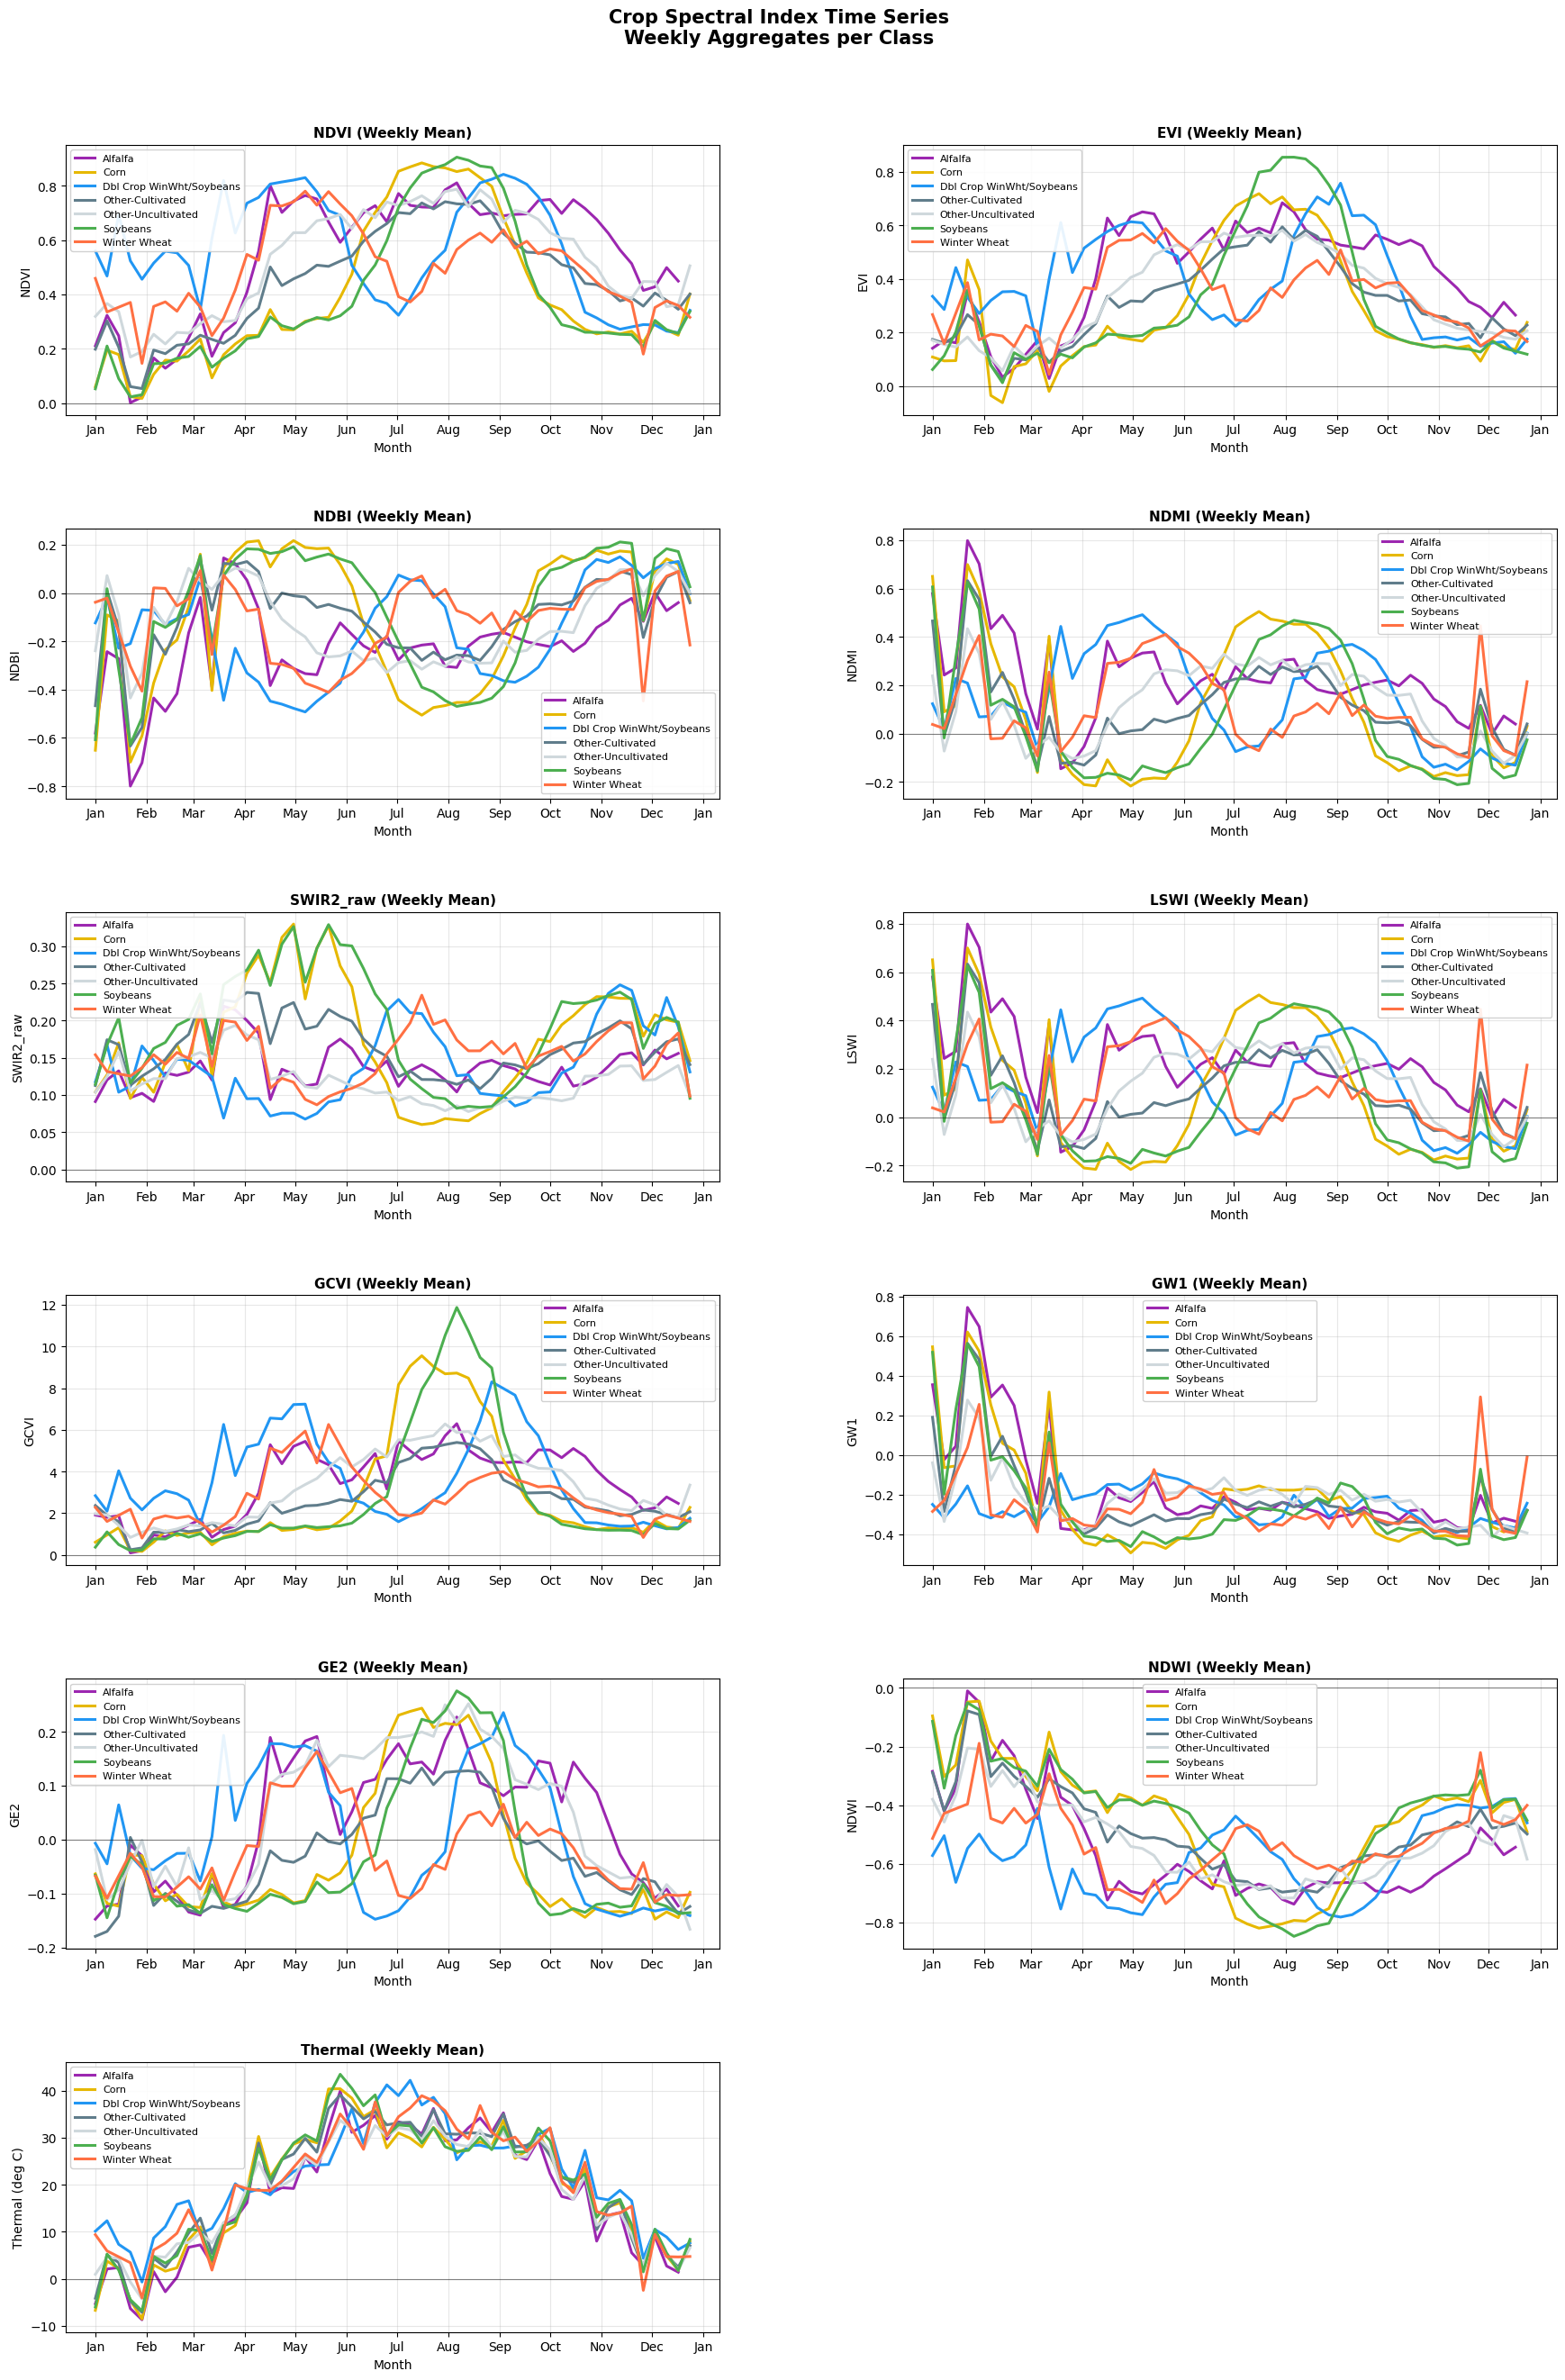

Plot saved to phase2_time_series_weekly.png


In [69]:
# -- Time series plots: weekly mean per crop for all indices --
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Generated some cleaner colors, makes things pop more on the graphs.
CROP_COLORS = {
    'Corn': '#e6b800',
    'Soybeans': '#4caf50',
    'Grass/Pasture': '#8d6e63',
    'Dbl Crop WinWht/Soybeans': '#2196f3',
    'Alfalfa': '#9c27b0',
    'Winter Wheat': '#ff7043',
    'Other-Cultivated': '#607d8b',
    'Other-Uncultivated': '#cfd8dc',
}
# Plot all index bands found in the extraction pipeline.
INDICES = INDEX_COLS.copy()

# Use crop names that actually exist in the current time-series table.
crop_names = sorted(ts_weekly_df['crop_name'].unique().tolist())

# Had some issues with bounds, this cleans those up for GCVI & Thermal 
n_indices = len(INDICES)
n_cols = 2
n_rows = math.ceil(n_indices / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 4.6 * n_rows),
    squeeze=False,
    constrained_layout=False,
 )
fig.suptitle(
    'Crop Spectral Index Time Series\nWeekly Aggregates per Class',
    fontsize=15,
    fontweight='bold',
    y=0.995,
 )

for ax, index in zip(axes.flat, INDICES):
    for crop_name in crop_names:
        crop_data = ts_weekly_df[ts_weekly_df['crop_name'] == crop_name].sort_values('date')
        if crop_data.empty:
            continue

        dates = crop_data['date']
        values = crop_data[index]
        ax.plot(
            dates,
            values,
            color=CROP_COLORS[crop_name],
            linewidth=2.2,
            label=crop_name,
        )
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.45)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.get_xticklabels(), rotation=0)
    ax.set_title(f'{index} (Weekly Mean)', fontweight='bold', fontsize=11)
    ax.set_xlabel('Month')
    ax.set_ylabel('Thermal (deg C)' if index == 'Thermal' else index)

    ax.legend(fontsize=8, loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)

# Hide any unused subplot axes.
for ax in axes.flat[n_indices:]:
    ax.set_visible(False)

# Increase spacing between panels.
plt.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.06, wspace=0.28, hspace=0.42)

plt.savefig('phase2_time_series_weekly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to phase2_time_series_weekly.png')

In [ ]:
# Phase 2.4: Phenological analysis and interpretation
# TODO (in markdown below, or in this cell):
# 1. Write an analysis addressing:
#    - Which crops are spectrally easy to distinguish? Why?
#    - Which crops are hard to separate? When/why do they overlap?
#    - When during the year are differences most pronounced?
#    - How does variability within each crop class compare?
# 2. Connect observations to the classification problem:
#    - What features or time windows are most useful for discrimination?
#    - Are there confusable pairs that might be problematic?
# 3. Cite specific patterns from the time series plots

## Phase 3: Classification System

Objective: Build, train, and rigorously evaluate a pixel-level crop classifier using full-year 2023 Landsat data.

**Deliverables**: Trained model, feature engineering justification, confusion matrix and per-class metrics, error analysis, discussion of model iterations

In [79]:
# Phase 3.1: Prepare training data from CDL and Landsat
# Build a tabular dataset from the time-series samples created in Phase 2.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Use computed index features, excluding weak contributors from prior importance analysis.
excluded_features = {'NDMI', 'LSWI', 'NDBI', 'GW1'}
# NDWI is intentionally NOT excluded; it is a new feature being evaluated.
base_feature_cols = [col for col in INDEX_COLS if col not in excluded_features]

required_cols = ['lon', 'lat', 'date', 'crop_name'] + base_feature_cols
missing_cols = [c for c in required_cols if c not in ts_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for modeling: {missing_cols}")

model_df = ts_df[required_cols].copy()
model_df = model_df.dropna(subset=['crop_name'])

# Keep rows with sufficient feature coverage.
model_df = model_df.dropna(subset=base_feature_cols, how='all')

# Add temporal feature as month indicator (1-12).
model_df['date'] = pd.to_datetime(model_df['date'])
model_df['month_indicator'] = model_df['date'].dt.month.astype(int)

class_labels = sorted(model_df['crop_name'].unique().tolist())

print(f"Prepared modeling dataset with {len(model_df):,} samples")
print(f"Number of classes: {len(class_labels)}")
print("Class counts:")
print(model_df['crop_name'].value_counts())
print("\nBase feature columns:")
print(base_feature_cols + ['month_indicator'])

# --- Define stratified train/test split first ---
# Splitting before computing context features avoids test leakage.
train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=SEED,
    stratify=model_df['crop_name'],
)

# --- Monthly context features (all months) ---
# For each month, compute train-set averages of all retained indices.
# Then flatten all months (m1..m12) into one global context vector and attach
# that full profile to every sample in train/test.
monthly_context = (
    train_df.groupby('month_indicator')[base_feature_cols]
    .mean()
    .reindex(range(1, 13))
)

# Fill missing month rows (if any) with per-feature train means.
feature_fallback = train_df[base_feature_cols].mean()
monthly_context = monthly_context.fillna(feature_fallback)

monthly_context_cols = []
monthly_context_values = {}
for month in range(1, 13):
    for col in base_feature_cols:
        ctx_col = f'{col}_m{month}_avg'
        monthly_context_cols.append(ctx_col)
        monthly_context_values[ctx_col] = float(monthly_context.loc[month, col])


def attach_full_monthly_context(df, context_values):
    df_out = df.copy()
    for col, val in context_values.items():
        df_out[col] = val
    return df_out


train_df = attach_full_monthly_context(train_df, monthly_context_values)
test_df = attach_full_monthly_context(test_df, monthly_context_values)

feature_cols = base_feature_cols + ['month_indicator'] + monthly_context_cols

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df['crop_name']
y_test = test_df['crop_name']

print(f"\nExtended feature set: {len(feature_cols)} features")
print(f"  Base spectral + month: {len(base_feature_cols) + 1}")
print(f"  Monthly context features (all months): {len(monthly_context_cols)}")

print(f"\nTrain/Test Split (stratified):")
print(f"  Train size: {len(X_train):,}")
print(f"  Test size:  {len(X_test):,}")
print("\nTrain set class counts:")
print(y_train.value_counts())

Prepared modeling dataset with 19,874 samples
Number of classes: 7
Class counts:
crop_name
Other-Uncultivated          2964
Winter Wheat                2879
Soybeans                    2858
Corn                        2846
Alfalfa                     2834
Other-Cultivated            2783
Dbl Crop WinWht/Soybeans    2710
Name: count, dtype: int64

Base feature columns:
['NDVI', 'EVI', 'SWIR2_raw', 'GCVI', 'GE2', 'NDWI', 'Thermal', 'month_indicator']

Extended feature set: 92 features
  Base spectral + month: 8
  Monthly context features (all months): 84

Train/Test Split (stratified):
  Train size: 15,899
  Test size:  3,975

Train set class counts:
crop_name
Other-Uncultivated          2371
Winter Wheat                2303
Soybeans                    2286
Corn                        2277
Alfalfa                     2267
Other-Cultivated            2227
Dbl Crop WinWht/Soybeans    2168
Name: count, dtype: int64


In [85]:
# Phase 3.2: Train Random Forest on full sample_training_pixels dataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=SEED,
        n_jobs=-1,
    ))
])

rf_pipeline.fit(X_train, y_train)

print(f"Random Forest trained on {len(X_train):,} samples (80% train split).")
print(f"Test set reserved: {len(X_test):,} samples.")
print(f"Number of classes: {len(class_labels)}")
print("Train set class counts:")
print(y_train.value_counts())

Random Forest trained on 15,899 samples (80% train split).
Test set reserved: 3,975 samples.
Number of classes: 7
Train set class counts:
crop_name
Other-Uncultivated          2371
Winter Wheat                2303
Soybeans                    2286
Corn                        2277
Alfalfa                     2267
Other-Cultivated            2227
Dbl Crop WinWht/Soybeans    2168
Name: count, dtype: int64


Test Set overall metrics (raw classes):
  Accuracy:    0.4860
  Macro F1:    0.4847
  Weighted F1: 0.4849
  Micro F1:    0.4860

Test Set per-class precision / recall / F1 (raw classes):
                   class  precision  recall  f1_score  support
Dbl Crop WinWht/Soybeans     0.6263  0.5720    0.5979      542
      Other-Uncultivated     0.5574  0.5565    0.5570      593
                Soybeans     0.5113  0.5542    0.5319      572
                 Alfalfa     0.4758  0.5538    0.5118      567
                    Corn     0.5000  0.4868    0.4933      569
            Winter Wheat     0.4434  0.4080    0.4250      576
        Other-Cultivated     0.2844  0.2680    0.2759      556

Test Set grouped metrics (Other-Cultivated + Other-Uncultivated -> Other):
  Accuracy:    0.5268
  Macro F1:    0.5210
  Weighted F1: 0.5269
  Micro F1:    0.5268

Test Set per-class precision / recall / F1 (grouped):
                   class  precision  recall  f1_score  support
Dbl Crop WinWht/Soybeans   

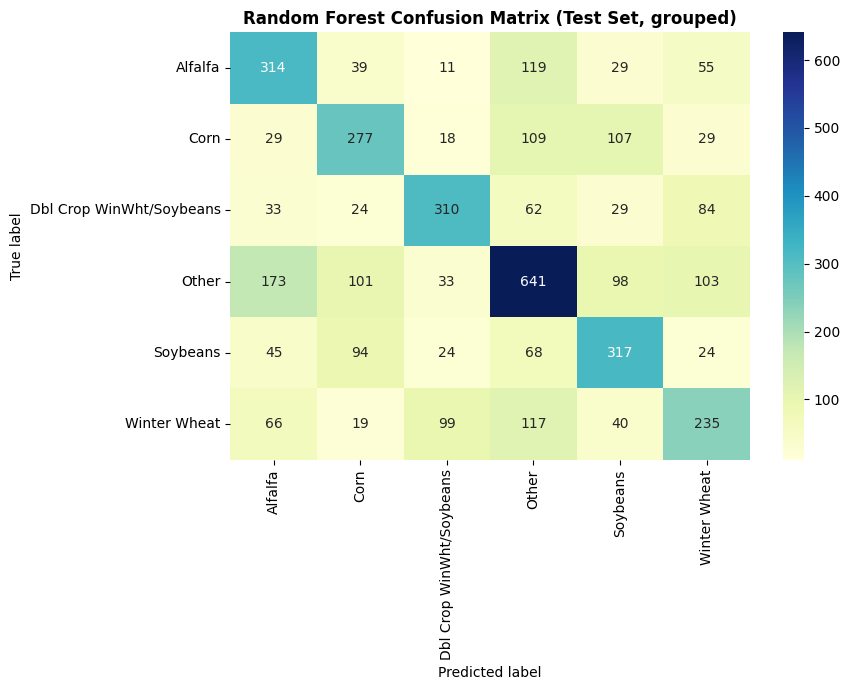

In [86]:
# Phase 3.3: Evaluate model on full dataset

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)


def collapse_other_label(label):
    if label in ('Other-Cultivated', 'Other-Uncultivated'):
        return 'Other'
    return label


def evaluate_classifier(model, X_eval, y_eval, labels, split_name='Full Dataset'):
    y_pred = model.predict(X_eval)

    # ---------- Raw (full class set) metrics ----------
    cm_raw = confusion_matrix(y_eval, y_pred, labels=labels)

    accuracy_raw = accuracy_score(y_eval, y_pred)
    macro_f1_raw = f1_score(y_eval, y_pred, average='macro')
    weighted_f1_raw = f1_score(y_eval, y_pred, average='weighted')
    micro_f1_raw = f1_score(y_eval, y_pred, average='micro')

    precision, recall, f1, support = precision_recall_fscore_support(
        y_eval,
        y_pred,
        labels=labels,
        zero_division=0,
    )

    metrics_df_raw = pd.DataFrame({
        'class': labels,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'support': support,
    }).sort_values('f1_score', ascending=False)

    print(f'{split_name} overall metrics (raw classes):')
    print(f"  Accuracy:    {accuracy_raw:.4f}")
    print(f"  Macro F1:    {macro_f1_raw:.4f}")
    print(f"  Weighted F1: {weighted_f1_raw:.4f}")
    print(f"  Micro F1:    {micro_f1_raw:.4f}")

    print(f'\n{split_name} per-class precision / recall / F1 (raw classes):')
    print(metrics_df_raw.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

    # ---------- Grouped review metrics (Other-* -> Other) ----------
    y_eval_grouped = pd.Series(y_eval).map(collapse_other_label)
    y_pred_grouped = pd.Series(y_pred).map(collapse_other_label)

    grouped_labels = []
    for lbl in labels:
        collapsed = collapse_other_label(lbl)
        if collapsed not in grouped_labels:
            grouped_labels.append(collapsed)

    cm_grouped = confusion_matrix(y_eval_grouped, y_pred_grouped, labels=grouped_labels)

    accuracy_grouped = accuracy_score(y_eval_grouped, y_pred_grouped)
    macro_f1_grouped = f1_score(y_eval_grouped, y_pred_grouped, average='macro', labels=grouped_labels, zero_division=0)
    weighted_f1_grouped = f1_score(y_eval_grouped, y_pred_grouped, average='weighted', labels=grouped_labels, zero_division=0)
    micro_f1_grouped = f1_score(y_eval_grouped, y_pred_grouped, average='micro', labels=grouped_labels, zero_division=0)

    precision_g, recall_g, f1_g, support_g = precision_recall_fscore_support(
        y_eval_grouped,
        y_pred_grouped,
        labels=grouped_labels,
        zero_division=0,
    )

    metrics_df_grouped = pd.DataFrame({
        'class': grouped_labels,
        'precision': precision_g,
        'recall': recall_g,
        'f1_score': f1_g,
        'support': support_g,
    }).sort_values('f1_score', ascending=False)

    print(f'\n{split_name} grouped metrics (Other-Cultivated + Other-Uncultivated -> Other):')
    print(f"  Accuracy:    {accuracy_grouped:.4f}")
    print(f"  Macro F1:    {macro_f1_grouped:.4f}")
    print(f"  Weighted F1: {weighted_f1_grouped:.4f}")
    print(f"  Micro F1:    {micro_f1_grouped:.4f}")

    print(f'\n{split_name} per-class precision / recall / F1 (grouped):')
    print(metrics_df_grouped.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

    print(f'\n{split_name} classification report (grouped):')
    print(classification_report(y_eval_grouped, y_pred_grouped, labels=grouped_labels, zero_division=0))

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm_grouped,
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        xticklabels=grouped_labels,
        yticklabels=grouped_labels,
    )
    plt.title(f'Random Forest Confusion Matrix ({split_name}, grouped)', fontweight='bold')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()

    return y_pred, cm_grouped, metrics_df_grouped, {
        'accuracy': accuracy_grouped,
        'macro_f1': macro_f1_grouped,
        'weighted_f1': weighted_f1_grouped,
        'micro_f1': micro_f1_grouped,
    }, grouped_labels


# Evaluate on test set
rf_y_pred, rf_cm, rf_class_metrics_df, rf_overall_metrics, grouped_class_labels = evaluate_classifier(
    rf_pipeline,
    X_test,
    y_test,
    class_labels,
    split_name='Test Set',
)

# Aliases for Cell 18 error analysis (backward compatibility)
cm = rf_cm
class_metrics_df = rf_class_metrics_df
overall_metrics = rf_overall_metrics

In [87]:
# Phase 3.4: Error analysis (grouped Other classes)

# Identify the most frequent misclassifications from the grouped confusion matrix.
cm_df = pd.DataFrame(cm, index=grouped_class_labels, columns=grouped_class_labels)

error_rows = []
for true_label in grouped_class_labels:
    for pred_label in grouped_class_labels:
        if true_label != pred_label:
            count = int(cm_df.loc[true_label, pred_label])
            if count > 0:
                error_rows.append({
                    'true_class': true_label,
                    'predicted_as': pred_label,
                    'count': count,
                })

if error_rows:
    error_df = pd.DataFrame(error_rows).sort_values('count', ascending=False)
    print('Top misclassifications (grouped labels):')
    print(error_df.head(10).to_string(index=False))
else:
    print('No off-diagonal errors found in grouped confusion matrix.')

lowest_recall_row = class_metrics_df.sort_values('recall', ascending=True).iloc[0]
print(
    f"\nLowest-recall grouped class: {lowest_recall_row['class']} "
    f"(recall={lowest_recall_row['recall']:.4f}, f1={lowest_recall_row['f1_score']:.4f})"
)

# Feature importances listed from least important to most important.
rf_model = rf_pipeline.named_steps['model']
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=True)

print('\nFeature importances (least -> most important):')
print(importance_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

print('\nLeast important features first:')
print(importance_df['feature'].tolist())

Top misclassifications (grouped labels):
  true_class             predicted_as  count
       Other                  Alfalfa    173
     Alfalfa                    Other    119
Winter Wheat                    Other    117
        Corn                    Other    109
        Corn                 Soybeans    107
       Other             Winter Wheat    103
       Other                     Corn    101
Winter Wheat Dbl Crop WinWht/Soybeans     99
       Other                 Soybeans     98
    Soybeans                     Corn     94

Lowest-recall grouped class: Winter Wheat (recall=0.4080, f1=0.4250)

Feature importances (least -> most important):
          feature  importance
      NDVI_m2_avg      0.0000
   Thermal_m1_avg      0.0000
      NDWI_m1_avg      0.0000
       GE2_m1_avg      0.0000
      GCVI_m1_avg      0.0000
 SWIR2_raw_m1_avg      0.0000
       EVI_m1_avg      0.0000
      NDVI_m1_avg      0.0000
       EVI_m3_avg      0.0000
      NDVI_m3_avg      0.0000
   Thermal_m2_av

In [ ]:
# Phase 3.5: CNN Classifier — full tabular feature set using PyTorch

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# Train CNN on the full tabular dataset (same split as Random Forest).
# This avoids restricting CNN to only pixels with complete 12-month profiles.
print(f"Using full RF split for CNN:")
print(f"  Train rows: {len(X_train):,}")
print(f"  Test rows:  {len(X_test):,}")
print(f"  Num features: {X_train.shape[1]}")

# --- Preprocess: fit only on train to avoid leakage ---
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_proc = scaler.fit_transform(X_train_imp).astype(np.float32)
X_test_proc = scaler.transform(X_test_imp).astype(np.float32)

# Label encoding aligned with class_labels from Phase 3.1
le = LabelEncoder()
le.fit(class_labels)
y_train_int = le.transform(y_train)
y_test_int = le.transform(y_test)
n_classes = len(le.classes_)

# Conv1D expects (batch, channels, sequence_length)
# Treat the tabular feature vector as a 1D sequence with 1 channel.
train_X_t = torch.from_numpy(X_train_proc).unsqueeze(1)
test_X_t = torch.from_numpy(X_test_proc).unsqueeze(1)
train_y_t = torch.from_numpy(y_train_int.astype(np.int64))
test_y_t = torch.from_numpy(y_test_int.astype(np.int64))

train_dataset = TensorDataset(train_X_t, train_y_t)
test_dataset = TensorDataset(test_X_t, test_y_t)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


class TabularCNN(nn.Module):
    def make_conv_block(self, in_channels, out_channels, kernel_size=3):
        padding = kernel_size // 2
        return [
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.ReLU(),
            nn.BatchNorm1d(out_channels),
        ]
    def __init__(self, n_features, n_classes):
        super(TabularCNN, self).__init__()
        self.conv_in = [1, 10, 14, 18, 22]
        self.conv_out = [10, 14, 18, 22, 26]
        self.conv = [nn.Sequential(*self.make_conv_block(in_ch, out_ch)) for in_ch, out_ch in zip(self.conv_in, self.conv_out)]
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(26, n_classes),
        )

    def forward(self, x):
        for conv in self.conv:
            x = conv(x)
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nTraining on: {device}")

cnn_model = TabularCNN(n_features=X_train.shape[1], n_classes=n_classes).to(device)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"CNN trainable parameters: {cnn_params:,}")
optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# --- Training loop ---
N_EPOCHS = 100
for epoch in range(1, N_EPOCHS + 1):
    cnn_model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = cnn_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += X_batch.size(0)

    avg_loss = total_loss / total if total > 0 else 0
    train_acc = correct / total if total > 0 else 0

    if epoch == 1 or epoch % 5 == 0 or epoch == N_EPOCHS:
        print(f"Epoch {epoch:>2}/{N_EPOCHS}  loss={avg_loss:.4f}  train_acc={train_acc:.4f}")

# --- CNN Evaluation ---
cnn_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = cnn_model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

cnn_y_pred_names = le.inverse_transform(np.array(all_preds))
cnn_y_true_names = le.inverse_transform(np.array(all_true))

# Group the two Other subclasses for reporting consistency.
cnn_y_pred_grouped = pd.Series(cnn_y_pred_names).map(collapse_other_label)
cnn_y_true_grouped = pd.Series(cnn_y_true_names).map(collapse_other_label)

cnn_accuracy = accuracy_score(cnn_y_true_grouped, cnn_y_pred_grouped)
cnn_macro_f1 = f1_score(cnn_y_true_grouped, cnn_y_pred_grouped, average='macro', labels=grouped_class_labels, zero_division=0)
cnn_cm = confusion_matrix(cnn_y_true_grouped, cnn_y_pred_grouped, labels=grouped_class_labels)

print(f"\nCNN Test Results (grouped Other classes):")
print(f"  Accuracy:  {cnn_accuracy:.4f}")
print(f"  Macro F1:  {cnn_macro_f1:.4f}")
print(f"\nClassification Report (grouped):")
print(classification_report(cnn_y_true_grouped, cnn_y_pred_grouped, labels=grouped_class_labels, zero_division=0))

Using full RF split for CNN:
  Train rows: 15,899
  Test rows:  3,975
  Num features: 92

Training on: cpu
CNN trainable parameters: 4,569
Epoch  1/100  loss=1.8809  train_acc=0.2461
Epoch  5/100  loss=1.5401  train_acc=0.4049
Epoch 10/100  loss=1.4467  train_acc=0.4387
Epoch 15/100  loss=1.3994  train_acc=0.4552
Epoch 20/100  loss=1.3736  train_acc=0.4692
Epoch 25/100  loss=1.3585  train_acc=0.4721
Epoch 30/100  loss=1.3398  train_acc=0.4820
Epoch 35/100  loss=1.3244  train_acc=0.4885
Epoch 40/100  loss=1.3165  train_acc=0.4909
Epoch 45/100  loss=1.3139  train_acc=0.4961
Epoch 50/100  loss=1.3009  train_acc=0.4973
Epoch 55/100  loss=1.2947  train_acc=0.5016
Epoch 60/100  loss=1.2812  train_acc=0.5058
Epoch 65/100  loss=1.2792  train_acc=0.5073
Epoch 70/100  loss=1.2656  train_acc=0.5124
Epoch 75/100  loss=1.2708  train_acc=0.5133
Epoch 80/100  loss=1.2740  train_acc=0.5095
Epoch 85/100  loss=1.2622  train_acc=0.5158
Epoch 90/100  loss=1.2604  train_acc=0.5122
Epoch 95/100  loss=1.2500

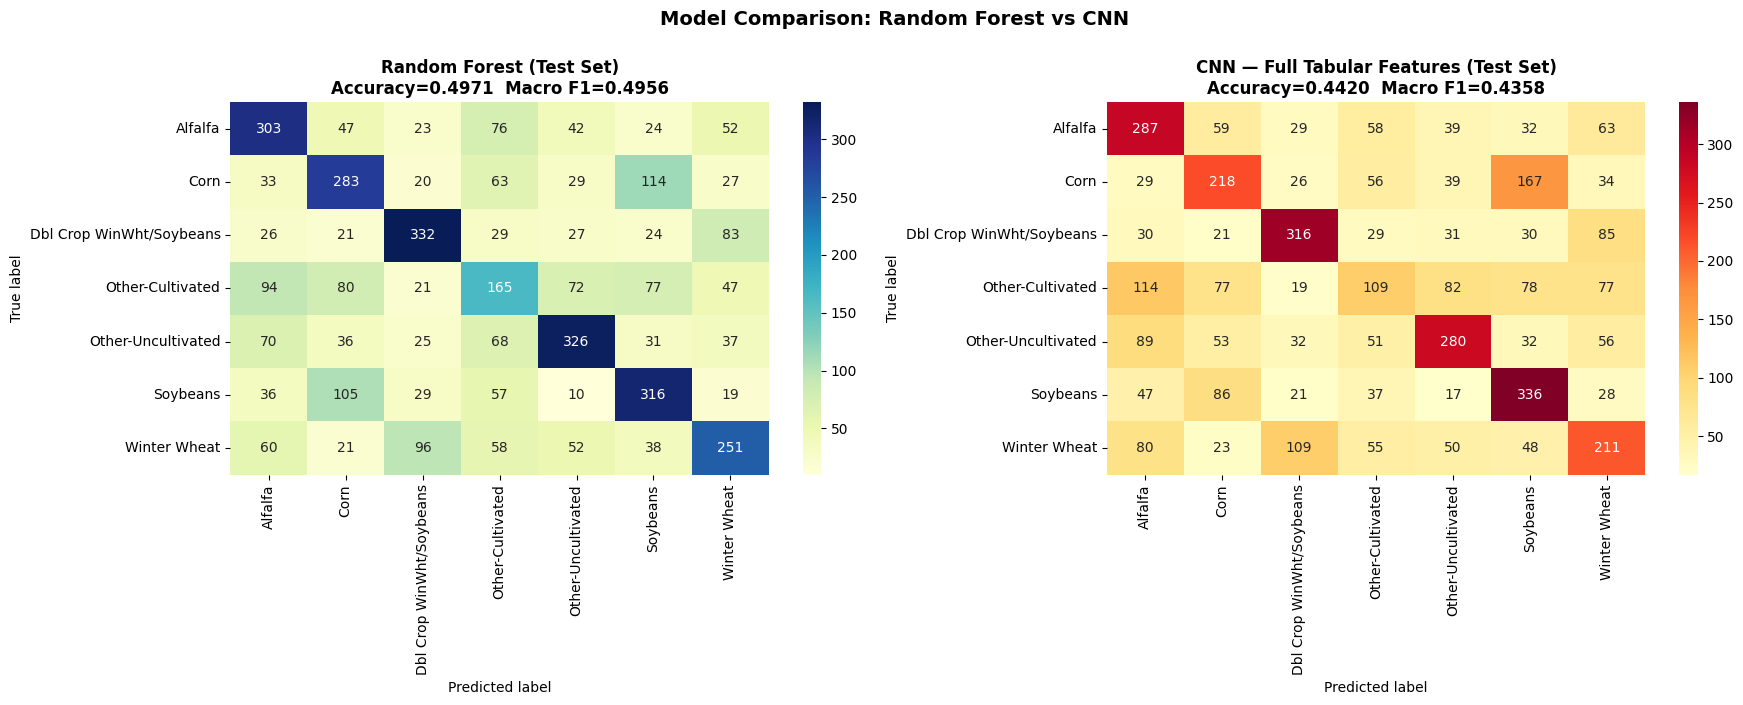


Model Summary: RandomForest vs CNN
Model                       Accuracy   Macro F1
---------------------------------------------
Random Forest                 0.4971     0.4956
CNN (Full Tabular)            0.4420     0.4358


In [ ]:
# Phase 3.6: Side-by-side confusion matrix — Random Forest vs CNN

import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- RF confusion matrix (left, grouped Other classes) ---
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=grouped_class_labels,
    yticklabels=grouped_class_labels,
    ax=ax1,
)
ax1.set_title(
    f'Random Forest (Test Set, grouped)\nAccuracy={rf_overall_metrics["accuracy"]:.4f}  '
    f'Macro F1={rf_overall_metrics["macro_f1"]:.4f}',
    fontweight='bold',
    fontsize=12,
)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')

# --- CNN confusion matrix (right, grouped Other classes) ---
sns.heatmap(
    cnn_cm,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=grouped_class_labels,
    yticklabels=grouped_class_labels,
    ax=ax2,
)
ax2.set_title(
    f'CNN — Full Tabular Features (Test Set, grouped)\nAccuracy={cnn_accuracy:.4f}  '
    f'Macro F1={cnn_macro_f1:.4f}',
    fontweight='bold',
    fontsize=12,
)
ax2.set_xlabel('Predicted label')
ax2.set_ylabel('True label')

plt.suptitle('Model Comparison: Random Forest vs CNN (Other classes grouped)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Summary comparison table
print("\n" + "="*50)
print("Model Summary: RandomForest vs CNN (Grouped Other)")
print("="*50)
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print(f"{'-'*45}")
print(f"{'Random Forest':<25} {rf_overall_metrics['accuracy']:>10.4f} {rf_overall_metrics['macro_f1']:>10.4f}")
print(f"{'CNN (Full Tabular)':<25} {cnn_accuracy:>10.4f} {cnn_macro_f1:>10.4f}")
print("="*50)

## Phase 4: Deployment and Generalization

Objective: Apply the trained model to 2024 imagery in two counties (one within training region, one outside) and assess generalization.

**Deliverables**: 30m classification maps for McLean County, IL and Renville County, MN; visual comparison with 2024 CDL; generalization analysis

In [ ]:
# Phase 4.1: McLean County, IL - in-region deployment
# TODO:
# 1. Get county boundary for McLean County, Illinois
# 2. Load 2024 Landsat imagery for this county
# 3. Compute the same features used in training (full year 2024)
# 4. Apply trained classifier to produce a prediction map
# 5. Export or save the classification map at 30m resolution
# 6. Display the map (color-coded by crop type)

In [ ]:
# Phase 4.2: Renville County, MN - out-of-region deployment
# TODO:
# 1. Get county boundary for Renville County, Minnesota
# 2. Load 2024 Landsat imagery for this county
# 3. Compute the same features used in training (full year 2024)
# 4. Apply trained classifier to produce a prediction map
# 5. Export or save the classification map at 30m resolution
# 6. Display the map (color-coded by crop type)

In [ ]:
# Phase 4.3: Load 2024 CDL ground truth for comparison
# TODO:
# 1. Load 2024 CDL
# 2. Extract CDL values for McLean County and Renville County
# 3. Keep only the 5 target crop classes (map CDL codes to class labels)
# 4. Store both CDL maps for later comparison

In [ ]:
# Phase 4.4: McLean County comparison - model prediction vs 2024 CDL
# TODO:
# 1. Create a side-by-side visualization of:
#    - Model prediction map (left)
#    - 2024 CDL ground truth (right)
# 2. Use consistent color scheme for crop types
# 3. Add a title and legend
# 4. Qualitatively assess: Do spatial patterns match? 
#    - Does the model capture large fields? County-scale trends?

In [ ]:
# Phase 4.5: Renville County comparison - model prediction vs 2024 CDL
# TODO:
# 1. Create a side-by-side visualization of:
#    - Model prediction map (left)
#    - 2024 CDL ground truth (right)
# 2. Use the same color scheme as McLean County for consistency
# 3. Add a title and legend
# 4. Qualitatively assess: 
#    - How does performance in Renville (out-of-region) compare visually to McLean?
#    - Does the model still capture large-scale patterns?

In [ ]:
# Phase 4.6: Generalization analysis
# TODO (in markdown):
# 1. Compare performance between McLean County (in-region) and Renville County (out-of-region):
#    - Which crops are well-predicted in both counties?
#    - Which crops degrade in the out-of-region deployment?
#    - Quantify if possible: pixel-level accuracy on each CDL target
# 2. Discuss temporal generalization (2023 training -> 2024 deployment):
#    - Did weather, crop varieties, or planting dates change?
#    - Are there systematic biases?
# 3. Discuss spatial generalization:
#    - What factors limit transferability to new regions?
#    - Agronomic differences (soil, climate, crop mix)?
#    - Technical factors (sensor drift, atmospheric effects)?
# 4. Overall assessment: Did the model generalize reasonably?

## Bonus: In-Season Prediction (Optional)

This section is for exploring whether your classifier can achieve reasonable performance using only data available before full year completion (e.g., imagery through July or August). This is the real-world motivation for crop classification.

**Note**: Build and evaluate the full-year baseline first (Phases 1-4) before attempting this bonus work.